# Radio cross-match

Cross-match the OVRO-LWA metacatalog against external radio reference catalogs. Matching is most reliable at similar frequency and angular resolution:

| Catalog | Frequency | Beam | Role |
| --- | --- | --- | --- |
| VLSSR | ~74 MHz | 80″ | 73 MHz subband merge QA (similar freq/resolution) |
| [NVSS](https://heasarc.gsfc.nasa.gov/w3browse/all/nvss.html) | 1.4 GHz | 45″ | Known-source association (Condon et al. 1998) |
| [VLASS QL epoch 1](https://cirada.ca/catalogues) | ~3 GHz | ~2.5″ | Known-source association (Gordon et al. 2021, [ApJS 255, 30](https://scixplorer.org/abs/2021ApJS..255...30G/abstract)) |

Reference catalog files live under `/fast/claw/catalogs/` (see `REFERENCE_CATALOGS_DIR` in `lwa_catalog.constants`).

**Matching:** configurable radius per side (LWA + reference), then pairwise
``sep ≤ max(radius_lwa, radius_ref)`` via ``associate_catalogs``. See
``CrossmatchRadiusSpec`` in the config cell (`mode`: ``beam`` | ``localization`` | ``fixed``).

**Flux comparisons:** prefer **total flux** on both sides when available (LWA `Total_flux_{band}`, VLASS `Total_flux`). VLSSR and the NVSS `CATALOG.FIT` table only publish peak intensity, so those comparisons fall back to peak.

**Photometric attach:** after the QA matches, `attach_radio_surveys_to_metacatalog` writes `Peak_flux_{survey}` / `Total_flux_{survey}` / `n_assoc_{survey}` onto existing LWA rows only (brightest hit prefers total flux; no unmatched survey seeds; LWA astrometry unchanged).

**Run cells in order.**


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog, resolve_metacatalog_path
from lwa_catalog.analyze import (
    CrossmatchRadiusSpec,
    LWA_CROSSMATCH_RADIUS_BEAM,
    LWA_CROSSMATCH_RADIUS_LOCALIZATION,
    NVSS_REFERENCE_RADIUS_BEAM,
    VLASS_REFERENCE_RADIUS_BEAM,
    VLSSR_REFERENCE_RADIUS_BEAM,
    NvssMatchConfig,
    VlassMatchConfig,
    VlssrMatchConfig,
    attach_radio_surveys_to_metacatalog,
    describe_crossmatch_radius,
    load_nvss_catalog,
    load_vlass_catalog,
    load_vlssr_catalog,
    match_catalog_to_nvss,
    match_catalog_to_vlass,
    match_catalog_to_vlssr,
    predict_flux_at_frequency_hz,
    resolve_band_flux,
    resolve_highest_frequency_flux,
    resolve_row_flux,
    summarize_nvss_match,
    summarize_vlass_match,
    summarize_vlssr_match,
)
from lwa_catalog.constants import (
    NVSS_BMAJ_ARCSEC,
    NVSS_DEFAULT_PATH,
    NVSS_FREQ_HZ,
    REFERENCE_CATALOGS_DIR,
    VLASS_BMAJ_ARCSEC,
    VLASS_DEFAULT_PATH,
    VLASS_FREQ_HZ,
    VLSSR_BMAJ_ARCSEC,
    VLSSR_DEFAULT_PATH,
    VLSSR_FREQ_HZ,
    band_frequency_hz,
)

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")
VLSSR_PATH = VLSSR_DEFAULT_PATH
NVSS_PATH = NVSS_DEFAULT_PATH
VLASS_PATH = VLASS_DEFAULT_PATH
QUALITY_FLAG_MASK = 33267  # HAS_NAN|INVALID_ASTROMETRY|UNPHYSICAL_FLUX|RESID_ABS_FAIL|RESID_PCTL_RMS|RESID_PCTL_MEAN|JITTER_FAIL|LARGE_SINGLE; set None to keep all rows

# Subband nearest VLSSR (~74 MHz) for native flux comparison.
VLSSR_LWA_BAND = "73MHz"

# --- cross-match radius (per catalog side) ---
# mode "beam"           — restoring beam (BMAJ_match / BMAJ); default for surveys
# mode "localization"   — 1σ position error (E_RA/E_DEC, cluster_jitter_rms_deg, or default_arcsec)
# mode "fixed"          — constant fixed_arcsec for every source
# sigma_scale           — multiply beam or 1σ radius (e.g. 3 for 3σ matching)

#LWA_MATCH_RADIUS = LWA_CROSSMATCH_RADIUS_BEAM
#LWA_MATCH_RADIUS = LWA_CROSSMATCH_RADIUS_LOCALIZATION
LWA_MATCH_RADIUS = CrossmatchRadiusSpec(mode="sigma_scale", fixed_arcsec=3)

VLSSR_REFERENCE_RADIUS = VLSSR_REFERENCE_RADIUS_BEAM
#VLSSR_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=VLSSR_BMAJ_ARCSEC)

NVSS_REFERENCE_RADIUS = NVSS_REFERENCE_RADIUS_BEAM
# NVSS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=NVSS_BMAJ_ARCSEC)
#NVSS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="localization", default_arcsec=1.5)

VLASS_REFERENCE_RADIUS = VLASS_REFERENCE_RADIUS_BEAM
# VLASS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=VLASS_BMAJ_ARCSEC)
#VLASS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="localization", default_arcsec=1.0)

layout = CatalogLayout(CATALOG_DIR)
vlssr_config = VlssrMatchConfig(
    catalog_path=VLSSR_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=VLSSR_REFERENCE_RADIUS,
)
nvss_config = NvssMatchConfig(
    catalog_path=NVSS_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=NVSS_REFERENCE_RADIUS,
)
vlass_config = VlassMatchConfig(
    catalog_path=VLASS_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=VLASS_REFERENCE_RADIUS,
)

print("CATALOG_DIR =", layout.root.resolve())
print("metacatalog path =", resolve_metacatalog_path(layout))
print("REFERENCE_CATALOGS_DIR =", REFERENCE_CATALOGS_DIR.resolve())
print("VLSSR_PATH =", Path(VLSSR_PATH).resolve())
print("NVSS_PATH =", Path(NVSS_PATH).resolve())
print("VLASS_PATH =", Path(VLASS_PATH).resolve())
print("QUALITY_FLAG_MASK =", QUALITY_FLAG_MASK)
print("VLSSR_LWA_BAND =", VLSSR_LWA_BAND)
print("LWA match radius:", describe_crossmatch_radius(LWA_MATCH_RADIUS))
print("VLSSR reference radius:", describe_crossmatch_radius(VLSSR_REFERENCE_RADIUS))
print("NVSS reference radius:", describe_crossmatch_radius(NVSS_REFERENCE_RADIUS))
print("VLASS reference radius:", describe_crossmatch_radius(VLASS_REFERENCE_RADIUS))


CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75_subband
metacatalog path = /fast/claw/metacatalog_coaddR-0.75_subband/metacatalog_quality.parquet
REFERENCE_CATALOGS_DIR = /fast/claw/catalogs
VLSSR_PATH = /fast/claw/catalogs/vlssr_radecpeak.txt
NVSS_PATH = /fast/claw/catalogs/nvss/CATALOG.FIT
VLASS_PATH = /fast/claw/catalogs/vlass/CIRADA_VLASS1QLv3.1_table1_components.csv.gz
QUALITY_FLAG_MASK = 33267
VLSSR_LWA_BAND = 73MHz
LWA match radius: beam (BMAJ)
VLSSR reference radius: beam (BMAJ, default 80.0″)
NVSS reference radius: beam (BMAJ, default 45.0″)
VLASS reference radius: beam (BMAJ, default 2.5″)


## Load metacatalog

Reads ``metacatalog_quality.parquet`` (quality-flagged fusion product). Every quality-cleared row is used for VLSSR / NVSS / VLASS; there is no Blue-band subset.

In [2]:
metacatalog = read_metacatalog(
    layout,
    prefer_quality=True,
    prefer_spectral=False,
    quality_mask=QUALITY_FLAG_MASK,
)

print(f"metacatalog rows: {len(metacatalog)}")
print(f"quality_flag present: {'quality_flag' in metacatalog.columns}")
print(f"spectral columns present: {any(c.startswith('spec_peak_') for c in metacatalog.columns)}")
print(f"Peak_flux_{VLSSR_LWA_BAND} present: {f'Peak_flux_{VLSSR_LWA_BAND}' in metacatalog.columns}")
print(f"Total_flux_{VLSSR_LWA_BAND} present: {f'Total_flux_{VLSSR_LWA_BAND}' in metacatalog.columns}")


metacatalog rows: 128352
quality_flag present: True
spectral columns present: False
Peak_flux_73MHz present: True


In [3]:
def build_unique_flux_table(
    selected_meta: pd.DataFrame,
    meta_flags: pd.DataFrame,
    ref_footprint: pd.DataFrame,
    *,
    count_col: str,
    positions_col: str,
    ref_freq_hz: float,
    lwa_flux_col: str,
) -> pd.DataFrame:
    """Build unique 1:1 matches with survey flux, native LWA flux, and extrapolated flux.

    Prefers total flux on both sides when available (falls back to peak).
    ``lwa_flux_jy`` is the highest-frequency LWA flux on the row.
    ``{lwa_flux_col}`` is the spectral-model extrapolation to ``ref_freq_hz``
    when ``spec_*`` columns exist (else NaN).
    """
    unique_flags = meta_flags.loc[meta_flags[count_col] == 1].copy()
    meta_by_id = selected_meta.set_index("meta_id", drop=False)
    records: list[dict] = []
    for _, flag in unique_flags.iterrows():
        positions = flag.get(positions_col, [])
        if len(positions) != 1:
            continue
        meta_id = flag["meta_id"]
        if meta_id not in meta_by_id.index:
            continue
        meta_row = meta_by_id.loc[meta_id]
        if isinstance(meta_row, pd.DataFrame):
            meta_row = meta_row.iloc[0]
        ref_row = ref_footprint.iloc[int(positions[0])]
        ref_flux = resolve_row_flux(ref_row, prefer_total=True)
        lwa_native, _, _ = resolve_highest_frequency_flux(meta_row, prefer_total=True)
        lwa_extrap = predict_flux_at_frequency_hz(
            meta_row, ref_freq_hz, flux_kind="total"
        )
        records.append(
            {
                "meta_id": meta_id,
                "RA": flag["RA"],
                "DEC": flag["DEC"],
                "ref_flux_jy": ref_flux,
                "lwa_flux_jy": lwa_native,
                lwa_flux_col: lwa_extrap,
                "log_ratio_native": (
                    np.log10(lwa_native / ref_flux)
                    if np.isfinite(lwa_native) and ref_flux > 0
                    else np.nan
                ),
                "log_ratio_extrap": (
                    np.log10(lwa_extrap / ref_flux)
                    if np.isfinite(lwa_extrap) and ref_flux > 0
                    else np.nan
                ),
            }
        )
    return pd.DataFrame.from_records(records)


def plot_unique_flux_check(
    flux_table: pd.DataFrame,
    *,
    title: str,
    lwa_flux_col: str,
    ref_label: str,
    ref_freq_hz: float | None = None,
) -> None:
    """Plot log10 LWA flux vs log10 survey flux for unique matches.

    Prefers spectral extrapolation to ``ref_freq_hz`` when available; otherwise
    falls back to the native highest-frequency LWA flux (total preferred).
    """
    use_extrap = (
        lwa_flux_col in flux_table.columns
        and flux_table[lwa_flux_col].notna().any()
    )
    if use_extrap:
        y_col = lwa_flux_col
        ratio_col = "log_ratio_extrap"
        freq = "" if ref_freq_hz is None else f" @ {ref_freq_hz / 1e9:.2f} GHz"
        y_label = f"log10 LWA extrapolated flux{freq}"
        mode = "extrapolated"
    else:
        y_col = "lwa_flux_jy"
        ratio_col = "log_ratio_native"
        y_label = "log10 LWA native flux (Jy)"
        mode = "native (no spec_* columns)"

    finite = flux_table.dropna(subset=[ratio_col])
    if finite.empty:
        print(f"No finite LWA vs {ref_label} flux pairs for plot ({mode}).")
        return

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(
        np.log10(finite["ref_flux_jy"]),
        np.log10(finite[y_col]),
        s=8,
        alpha=0.35,
    )
    lim = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel(f"log10 {ref_label} flux (Jy)")
    ax.set_ylabel(y_label)
    ax.set_title(f"{title} [{mode}]")
    plt.show()
    print(
        f"plotted {len(finite)} unique matches "
        f"(median log10 LWA/{ref_label} = {finite[ratio_col].median():+.3f})"
    )


## VLSSR cross-match (~74 MHz)

Post-hoc QA against the VLSSR reference catalog at similar frequency and resolution to the **73 MHz** subband.

**Primary metric:** completeness — fraction of quality-cleared metacatalog rows that match ≥1 VLSSR source within the match radius.

**Failure-mode metric:** VLSSR over-splitting — one VLSSR source matched by multiple metacatalog rows.

In [4]:
vlssr = load_vlssr_catalog(VLSSR_PATH)
print(f"VLSSR rows: {len(vlssr):,}")
vlssr_result = match_catalog_to_vlssr(metacatalog, vlssr=vlssr, config=vlssr_config)
print(summarize_vlssr_match(vlssr_result))

VLSSR rows: 92,965
LWA target rows:              128352
VLSSR footprint (Dec box):     92965
Meta matched (>=1 VLSSR):      54944
Blue completeness:            0.428
VLSSR matched (>=1 meta):      55899
VLSSR recovery:               0.601
VLSSR over-split (n_meta>1):       7
Meta multi-VLSSR (n_vlssr>1):    847
Max VLSSR hits per meta:           8


In [5]:
vlssr_meta_flags = vlssr_result.meta_flags
vlssr_ref_flags = vlssr_result.vlssr_flags

print("VLSSR hits per meta (value_counts):")
display(vlssr_meta_flags["n_vlssr"].value_counts().sort_index().head(20))

vlssr_incomplete = vlssr_meta_flags.loc[~vlssr_meta_flags["matched"]]
print(f"\nIncomplete metacatalog rows (no VLSSR match, first 20 of {len(vlssr_incomplete)}):")
display(vlssr_incomplete.head(20))

vlssr_oversplit = vlssr_ref_flags.loc[vlssr_ref_flags["oversplit"]]
print(f"\nVLSSR over-split rows (first 20 of {len(vlssr_oversplit)}):")
display(vlssr_oversplit.head(20))

VLSSR hits per meta (value_counts):


n_vlssr
0    73408
1    54097
2      762
3       65
4       15
5        3
7        1
8        1
Name: count, dtype: int64


Incomplete metacatalog rows (no VLSSR match, first 20 of 73408):


,meta_id,RA,DEC,n_vlssr,vlssr_positions,matched
0,1035,68.926554,29.690979,0,[],False
1,445,69.059195,29.705322,0,[],False
2,93624,259.840362,-1.186728,0,[],False
3,6061,6.872708,64.094751,0,[],False
5,131905,5.725083,64.293613,0,[],False
7,137016,76.121806,38.381960,0,[],False
9,94089,303.805148,23.602798,0,[],False
10,16672,64.472652,38.203402,0,[],False
11,136274,64.439892,37.733767,0,[],False
12,1489,349.812663,58.042586,0,[],False



VLSSR over-split rows (first 20 of 7):


,vlssr_pos,RA,DEC,Peak_flux,n_meta,meta_ids,oversplit
36311,36311,127.834961,32.310543,3.755035,2,"[97183, 10194]",True
42801,42801,151.060676,31.926027,1.029270,2,"[36913, 93590]",True
52945,52945,189.037029,16.639414,3.186285,2,"[119252, 94052]",True
58189,58189,207.973625,7.219990,0.673813,2,"[34086, 94140]",True
65761,65761,237.907728,20.067612,1.234440,2,"[7485, 94005]",True
67273,67273,244.364036,35.083703,1.068761,2,"[93708, 6827]",True
80509,80509,316.032861,76.552698,51.366451,2,"[127333, 333]",True


unique VLSSR matches: 54097
with LWA 73MHz peak flux: 50597


,meta_id,vlssr_peak_jy,lwa_peak_73mhz_jy,log_ratio
0,94,45.291161,54.864157,0.083275
1,120363,0.723078,1.760635,0.386484
2,62,40.086720,43.097054,0.031447
3,20379,1.858513,1.778531,-0.019104
4,12330,3.209942,2.763388,-0.065055
5,653,17.341331,13.861029,-0.097287
6,116,10.163090,32.646285,0.506808
7,1332,1.082248,NaN,NaN
8,99712,4.831933,5.083692,0.022058
9,11,112.113564,5.083692,-1.343479


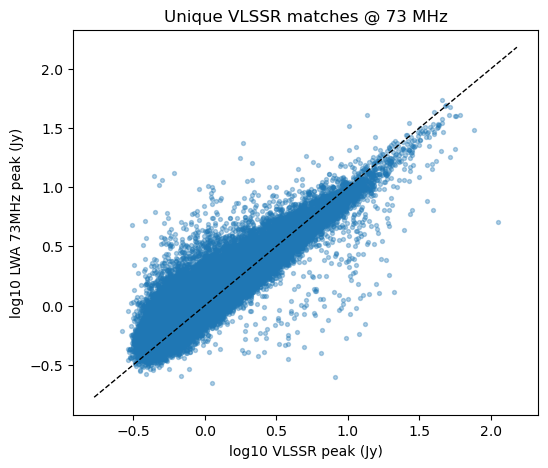

In [6]:
vlssr_total_col = f"Total_flux_{VLSSR_LWA_BAND}"
vlssr_peak_col = f"Peak_flux_{VLSSR_LWA_BAND}"
vlssr_freq_hz = band_frequency_hz(VLSSR_LWA_BAND)
meta_by_id = metacatalog.set_index("meta_id", drop=False)
vlssr_unique = vlssr_meta_flags.loc[vlssr_meta_flags["n_vlssr"] == 1].copy()

vlssr_flux_records: list[dict] = []
for _, flag in vlssr_unique.iterrows():
    positions = flag.get("vlssr_positions", [])
    if len(positions) != 1:
        continue
    meta_id = flag["meta_id"]
    if meta_id not in meta_by_id.index:
        continue
    meta_row = meta_by_id.loc[meta_id]
    if isinstance(meta_row, pd.DataFrame):
        meta_row = meta_row.iloc[0]
    ref_row = vlssr_result.vlssr_footprint.iloc[int(positions[0])]
    # VLSSR publishes peak intensity only.
    ref_flux = resolve_row_flux(ref_row, prefer_total=True)
    lwa_flux = resolve_band_flux(meta_row, VLSSR_LWA_BAND, prefer_total=True)
    if not np.isfinite(lwa_flux) or lwa_flux <= 0.0:
        lwa_flux = float(
            predict_flux_at_frequency_hz(meta_row, VLSSR_FREQ_HZ, flux_kind="total")
        )
    vlssr_flux_records.append(
        {
            "meta_id": meta_id,
            "vlssr_flux_jy": ref_flux,
            "lwa_flux_73mhz_jy": lwa_flux,
            "log_ratio": np.log10(lwa_flux / ref_flux)
            if np.isfinite(lwa_flux) and ref_flux > 0
            else np.nan,
        }
    )

vlssr_flux_table = pd.DataFrame.from_records(vlssr_flux_records)
print(f"unique VLSSR matches: {len(vlssr_unique)}")
print(
    f"with LWA {VLSSR_LWA_BAND} total/peak flux: "
    f"{vlssr_flux_table['lwa_flux_73mhz_jy'].notna().sum()}"
)
print(f"LWA total column present: {vlssr_total_col in metacatalog.columns}")
print(f"LWA peak column present: {vlssr_peak_col in metacatalog.columns}")
display(vlssr_flux_table.head(20))

finite = vlssr_flux_table.dropna(subset=["log_ratio"])
if not finite.empty:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(
        np.log10(finite["vlssr_flux_jy"]),
        np.log10(finite["lwa_flux_73mhz_jy"]),
        s=8,
        alpha=0.35,
    )
    lim = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel("log10 VLSSR peak (Jy)")
    ax.set_ylabel(f"log10 LWA {VLSSR_LWA_BAND} total/peak (Jy)")
    ax.set_title(f"Unique VLSSR matches @ {vlssr_freq_hz / 1e6:.0f} MHz")
    plt.show()


## NVSS cross-match (1.4 GHz)

Loads ~1.8M rows from the NRAO FITS table (30–60 s on first read).

In [7]:
nvss = load_nvss_catalog(NVSS_PATH)
print(f"NVSS rows: {len(nvss):,}")
print(f"Dec range: {nvss['DEC'].min():.2f} .. {nvss['DEC'].max():.2f}")
nvss_result = match_catalog_to_nvss(metacatalog, nvss=nvss, config=nvss_config)
print(summarize_nvss_match(nvss_result))

NVSS rows: 1,810,672
Dec range: -40.43 .. 89.82
LWA target rows:              128352
NVSS footprint (Dec box):     1807298
Meta matched (>=1 NVSS):       54718
Match completeness:           0.426
Meta unique match (n=1):       45897
Unique match fraction:        0.358
NVSS matched (>=1 meta):       66955
NVSS recovery:                0.037
NVSS over-split (n_meta>1):       25
Meta multi-NVSS (n_nvss>1):     8821
Max NVSS hits per meta:           18

NVSS reference frequency:     1.40 GHz


In [8]:
nvss_meta_flags = nvss_result.meta_flags
nvss_flags = nvss_result.nvss_flags

print("NVSS hits per meta (value_counts):")
display(nvss_meta_flags["n_nvss"].value_counts().sort_index().head(20))

nvss_unmatched = nvss_meta_flags.loc[~nvss_meta_flags["matched"]]
print(f"\nUnmatched meta rows (first 20 of {len(nvss_unmatched)}):")
display(nvss_unmatched.head(20))

NVSS hits per meta (value_counts):


n_nvss
0     73634
1     45897
2      6704
3      1429
4       406
5       145
6        61
7        30
8        20
9         4
10        8
11        5
12        3
13        1
16        3
17        1
18        1
Name: count, dtype: int64


Unmatched meta rows (first 20 of 73634):


,meta_id,RA,DEC,n_nvss,nvss_positions,matched
0,1035,68.926554,29.690979,0,[],False
2,93624,259.840362,-1.186728,0,[],False
3,6061,6.872708,64.094751,0,[],False
5,131905,5.725083,64.293613,0,[],False
7,137016,76.121806,38.381960,0,[],False
9,94089,303.805148,23.602798,0,[],False
10,16672,64.472652,38.203402,0,[],False
11,136274,64.439892,37.733767,0,[],False
12,1489,349.812663,58.042586,0,[],False
13,127496,349.628010,57.941507,0,[],False


unique NVSS matches: 45897
with LWA native peak: 45897
with spectral extrapolation to 1.4 GHz: 0


,meta_id,RA,DEC,ref_peak_jy,lwa_peak_jy,lwa_peak_1p4ghz_jy,log_ratio_native,log_ratio_extrap
0,5857,59.526966,10.447862,0.101325,3.544423,NaN,1.543831,NaN
1,131757,123.646088,48.287796,0.004681,4.021953,NaN,2.934126,NaN
2,15235,341.178533,39.821945,0.002469,2.052209,NaN,2.919672,NaN
3,34162,354.330180,27.130598,0.003420,1.174664,NaN,2.535882,NaN
4,3470,228.955571,7.157914,0.003025,4.610643,NaN,3.182990,NaN
5,20379,140.362609,45.917749,0.165735,1.693122,NaN,1.009275,NaN
6,47079,294.686496,21.726134,0.012869,0.910956,NaN,1.849965,NaN
7,12330,295.150212,21.666482,0.149785,2.339689,NaN,1.193691,NaN
8,653,294.896775,21.591406,0.038437,10.301407,NaN,2.428146,NaN
9,55976,35.735472,43.186069,0.020058,0.783894,NaN,1.591960,NaN


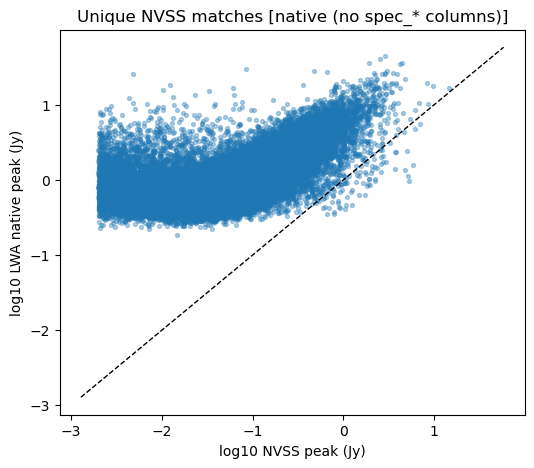

plotted 45897 unique matches (median log10 LWA/NVSS = +1.118)


In [9]:
nvss_flux_table = build_unique_flux_table(
    metacatalog,
    nvss_meta_flags,
    nvss_result.nvss_footprint,
    count_col="n_nvss",
    positions_col="nvss_positions",
    ref_freq_hz=NVSS_FREQ_HZ,
    lwa_flux_col="lwa_flux_1p4ghz_jy",
)
print(f"unique NVSS matches: {(nvss_meta_flags['n_nvss'] == 1).sum()}")
print(f"with LWA native flux: {nvss_flux_table['lwa_flux_jy'].notna().sum()}")
print(
    "with spectral extrapolation to 1.4 GHz: "
    f"{nvss_flux_table['lwa_flux_1p4ghz_jy'].notna().sum()}"
)
display(nvss_flux_table.head(20))
plot_unique_flux_check(
    nvss_flux_table,
    title="Unique NVSS matches",
    lwa_flux_col="lwa_flux_1p4ghz_jy",
    ref_label="NVSS",
    ref_freq_hz=NVSS_FREQ_HZ,
)


## VLASS cross-match (~3 GHz)

Loads the CIRADA QL epoch 1 component table with recommended quality flags (`Duplicate_flag <= 1`, `Quality_flag in (0, 4)`, `S_Code != 'E'`). First read can take several minutes.

In [10]:
vlass = load_vlass_catalog(VLASS_PATH, config=vlass_config)
print(f"VLASS rows (after quality filter): {len(vlass):,}")
print(f"Dec range: {vlass['DEC'].min():.2f} .. {vlass['DEC'].max():.2f}")
vlass_result = match_catalog_to_vlass(metacatalog, vlass=vlass, config=vlass_config)
print(summarize_vlass_match(vlass_result))

VLASS rows (after quality filter): 1,874,645
Dec range: -40.02 .. 89.82
LWA target rows:              128352
VLASS footprint (Dec box):    1874458
Meta matched (>=1 VLASS):      39260
Match completeness:           0.306
Meta unique match (n=1):       15399
Unique match fraction:        0.120
VLASS matched (>=1 meta):      80963
VLASS recovery:               0.043
VLASS over-split (n_meta>1):      18
Meta multi-VLASS (n_vlass>1):  23861
Max VLASS hits per meta:          15

VLASS reference frequency:    3.00 GHz


In [11]:
vlass_meta_flags = vlass_result.meta_flags
vlass_ref_flags = vlass_result.vlass_flags

print("VLASS hits per meta (value_counts):")
display(vlass_meta_flags["n_vlass"].value_counts().sort_index().head(20))

vlass_unmatched = vlass_meta_flags.loc[~vlass_meta_flags["matched"]]
print(f"\nUnmatched meta rows (first 20 of {len(vlass_unmatched)}):")
display(vlass_unmatched.head(20))

vlass_oversplit = vlass_ref_flags.loc[vlass_ref_flags["oversplit"]]
print(f"\nVLASS over-split rows (first 20 of {len(vlass_oversplit)}):")
display(vlass_oversplit.head(20))

VLASS hits per meta (value_counts):


n_vlass
0     89092
1     15399
2     13566
3      6061
4      2422
5      1011
6       427
7       197
8        90
9        45
10       20
11       12
12        8
15        2
Name: count, dtype: int64


Unmatched meta rows (first 20 of 89092):


,meta_id,RA,DEC,n_vlass,vlass_positions,matched
0,1035,68.926554,29.690979,0,[],False
1,445,69.059195,29.705322,0,[],False
2,93624,259.840362,-1.186728,0,[],False
3,6061,6.872708,64.094751,0,[],False
4,93567,6.176412,64.120954,0,[],False
5,131905,5.725083,64.293613,0,[],False
7,137016,76.121806,38.381960,0,[],False
9,94089,303.805148,23.602798,0,[],False
10,16672,64.472652,38.203402,0,[],False
11,136274,64.439892,37.733767,0,[],False



VLASS over-split rows (first 20 of 18):


,vlass_pos,RA,DEC,Peak_flux,Component_name,n_meta,meta_ids,oversplit
167227,167227,157.239826,78.836325,1.215803,VLASS1QLCIR J102857.55+785010.7,2,"[119223, 4678]",True
461241,461241,316.020098,76.554967,284.288585,VLASS1QLCIR J210404.82+763317.8,2,"[127333, 333]",True
461242,461242,316.035549,76.555444,3.451841,VLASS1QLCIR J210408.53+763319.5,2,"[127333, 333]",True
461243,461243,316.036216,76.550387,415.732760,VLASS1QLCIR J210408.69+763301.3,2,"[127333, 333]",True
461244,461244,316.053307,76.550659,3.153103,VLASS1QLCIR J210412.79+763302.3,2,"[127333, 333]",True
461246,461246,316.075809,76.551267,2.863042,VLASS1QLCIR J210418.19+763304.5,2,"[127333, 333]",True
550670,550670,203.858054,58.733350,498.592596,VLASS1QLCIR J133525.93+584400.0,2,"[15091, 93978]",True
550671,550671,203.865303,58.736292,3.333190,VLASS1QLCIR J133527.67+584410.6,2,"[15091, 93978]",True
729855,729855,151.065593,31.926658,8.612656,VLASS1QLCIR J100415.74+315535.9,2,"[36913, 93590]",True
729856,729856,151.066231,31.928590,13.018060,VLASS1QLCIR J100415.89+315542.9,2,"[36913, 93590]",True


unique VLASS matches: 15399
with LWA native peak: 15399
with spectral extrapolation to 3 GHz: 0


,meta_id,RA,DEC,ref_peak_jy,lwa_peak_jy,lwa_peak_3ghz_jy,log_ratio_native,log_ratio_extrap
0,399,6.484856,64.166965,1.488330,13.152422,NaN,0.946307,NaN
1,5857,59.526966,10.447862,22.706182,3.544423,NaN,-0.806599,NaN
2,62,230.450889,7.699906,2.966622,35.797243,NaN,1.081587,NaN
3,3470,228.955571,7.157914,4.787258,4.610643,NaN,-0.016325,NaN
4,47079,294.686496,21.726134,3.775500,0.910956,NaN,-0.617477,NaN
5,12330,295.150212,21.666482,46.133201,2.339689,NaN,-1.294855,NaN
6,653,294.896775,21.591406,1.629386,10.301407,NaN,0.800873,NaN
7,11400,150.651124,28.841272,7.263928,2.453243,NaN,-0.471431,NaN
8,317,228.372693,26.128668,106.060406,14.971050,NaN,-0.850301,NaN
9,211,354.114506,21.149542,8.583602,18.756325,NaN,0.339478,NaN


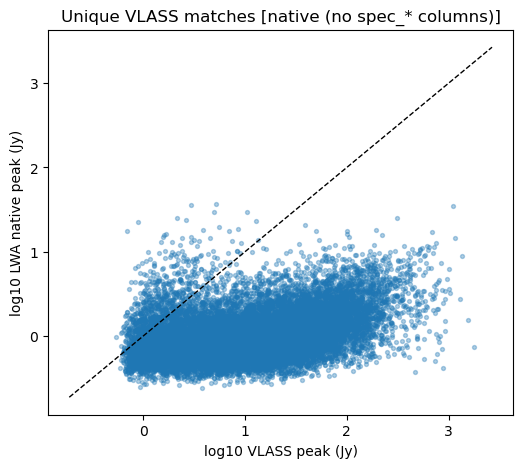

plotted 15399 unique matches (median log10 LWA/VLASS = -1.071)


In [12]:
vlass_flux_table = build_unique_flux_table(
    metacatalog,
    vlass_meta_flags,
    vlass_result.vlass_footprint,
    count_col="n_vlass",
    positions_col="vlass_positions",
    ref_freq_hz=VLASS_FREQ_HZ,
    lwa_flux_col="lwa_flux_3ghz_jy",
)
print(f"unique VLASS matches: {(vlass_meta_flags['n_vlass'] == 1).sum()}")
print(f"with LWA native flux: {vlass_flux_table['lwa_flux_jy'].notna().sum()}")
print(
    "with spectral extrapolation to 3 GHz: "
    f"{vlass_flux_table['lwa_flux_3ghz_jy'].notna().sum()}"
)
display(vlass_flux_table.head(20))
plot_unique_flux_check(
    vlass_flux_table,
    title="Unique VLASS matches",
    lwa_flux_col="lwa_flux_3ghz_jy",
    ref_label="VLASS",
    ref_freq_hz=VLASS_FREQ_HZ,
)


## Attach surveys as photometric bands

Reuse the loaded reference catalogs as extra frequency channels on the LWA metacatalog (`VLASS`, `NVSS`, `VLSSR`). Unmatched survey sources are dropped. Top-level `RA`/`DEC`/`BMAJ_match` stay on the LWA row; stored flux is the brightest hit preferring `Total_flux` when available (`n_assoc_*` counts every hit).

This is independent of the QA `match_catalog_to_*` summaries above. Reload the notebook from disk and restart the kernel before running if imports changed.


In [13]:
survey_meta = attach_radio_surveys_to_metacatalog(
    metacatalog,
    surveys={"VLASS": vlass, "NVSS": nvss, "VLSSR": vlssr},
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radii={
        "VLASS": VLASS_REFERENCE_RADIUS,
        "NVSS": NVSS_REFERENCE_RADIUS,
        "VLSSR": VLSSR_REFERENCE_RADIUS,
    },
)
assert len(survey_meta) == len(metacatalog)
print(f"LWA rows: {len(survey_meta)} (unchanged)")
for band in ("VLASS", "NVSS", "VLSSR"):
    n_assoc = survey_meta[f"n_assoc_{band}"]
    n_hit = int((n_assoc >= 1).sum())
    n_multi = int((n_assoc > 1).sum())
    in_bands = survey_meta["bands_present"].astype(str).str.contains(band, regex=False)
    print(
        f"{band:6s}  matched {n_hit:6d}  "
        f"multi {n_multi:5d}  "
        f"in bands_present {int(in_bands.sum()):6d}  "
        f"max n_assoc {int(n_assoc.max())}"
    )
cols = [
    "meta_id",
    "RA",
    "DEC",
    "origin_band",
    "astrometry_band",
    "bands_present",
    "n_assoc_VLASS",
    "Total_flux_VLASS",
    "Peak_flux_VLASS",
    "n_assoc_NVSS",
    "Total_flux_NVSS",
    "Peak_flux_NVSS",
    "n_assoc_VLSSR",
    "Total_flux_VLSSR",
    "Peak_flux_VLSSR",
]
display(survey_meta[[c for c in cols if c in survey_meta.columns]].head(12))


LWA rows: 128352 (unchanged)
VLASS   matched  39260  multi 23861  in bands_present  39260  max n_assoc 15
NVSS    matched  54718  multi  8821  in bands_present  54718  max n_assoc 18
VLSSR   matched  54944  multi   847  in bands_present  54944  max n_assoc 8


,meta_id,RA,DEC,origin_band,astrometry_band,bands_present,n_assoc_VLASS,Peak_flux_VLASS,n_assoc_NVSS,Peak_flux_NVSS,n_assoc_VLSSR,Peak_flux_VLSSR
0,1035,68.926554,29.690979,82MHz,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,50MHz,36MH...",0,NaN,0,NaN,0,NaN
1,445,69.059195,29.705322,82MHz,82MHz,"82MHz,69MHz,64MHz,59MHz,50MHz,36MHz,23MHz,18MH...",0,NaN,3,0.025327,0,NaN
2,93624,259.840362,-1.186728,78MHz,78MHz,"78MHz,73MHz,64MHz,23MHz,18MHz",0,NaN,0,NaN,0,NaN
3,6061,6.872708,64.094751,82MHz,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,23MHz,18MHz",0,NaN,0,NaN,0,NaN
4,93567,6.176412,64.120954,78MHz,78MHz,"78MHz,73MHz,69MHz,64MHz,59MHz,50MHz,36MHz,23MH...",0,NaN,2,0.554157,4,9.811930
5,131905,5.725083,64.293613,64MHz,64MHz,"64MHz,23MHz,18MHz",0,NaN,0,NaN,0,NaN
6,399,6.484856,64.166965,82MHz,82MHz,"82MHz,59MHz,50MHz,36MHz,23MHz,18MHz,32MHz,27MH...",1,1.488330,4,0.726855,5,17.617620
7,137016,76.121806,38.381960,50MHz,50MHz,"50MHz,23MHz,18MHz",0,NaN,0,NaN,0,NaN
8,13,226.242984,26.020485,82MHz,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,50MHz,36MH...",3,49.014043,10,0.799348,4,28.966551
9,94089,303.805148,23.602798,78MHz,78MHz,"78MHz,59MHz,46MHz,36MHz,32MHz,27MHz,23MHz,18MHz",0,NaN,0,NaN,0,NaN
